# Traveling Salesman Problem (TSP) using the genetic algorithm



In [79]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
%cd '/content/drive/MyDrive/2023-01/알고리즘/Genetic_algorithm_project_data'

/content/drive/MyDrive/2023-01/알고리즘/Genetic_algorithm_project_data


In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [82]:
# Data Load
atlanta = pd.read_csv("Atlanta.csv")
Cincinnati = pd.read_csv("Cincinnati.csv")
Philadelphia = pd.read_csv("Philadelphia.csv")
df=Cincinnati #change according to the selected city

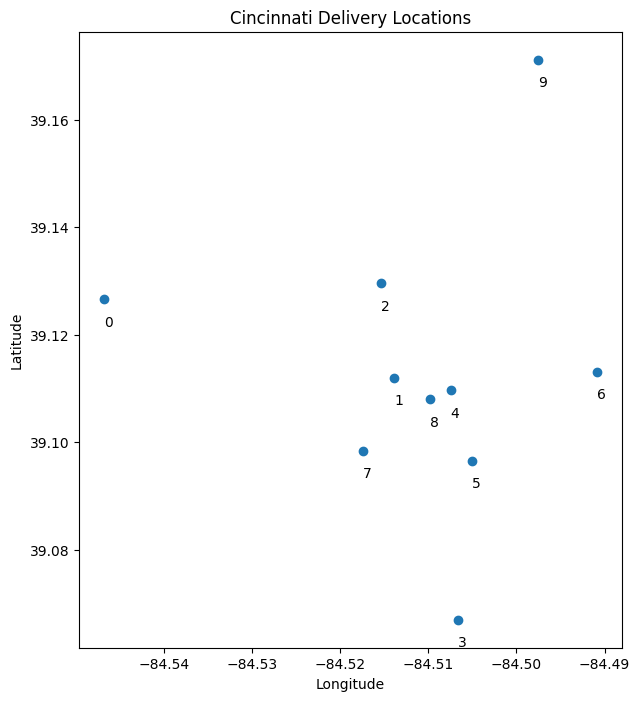

In [83]:
plt.figure(figsize = (7, 8))

# plot showing the delivery locations for the selected cities
plt.scatter(df['Longitude (deg)'], df['Latitude (deg)'])

# Add labels and a title to the plot
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Cincinnati Delivery Locations')  #change according to the selected city

# Add location index as annotations to the plot
for i in range(len(df)):
    plt.text(df.loc[i, 'Longitude (deg)'], df.loc[i, 'Latitude (deg)']-0.005, str(df.loc[i, 'Index']))

# Show the plot
plt.show()

In [84]:
#Create an empty matrix of size n x n, where n is the number of locations
n = len(df)
d_a_matrix = [[0] * n for _ in range(n)]

In [85]:
! pip install haversine

from haversine import haversine 
'''
#Example
loc1 = (Latitude, Longitude)
loc2 = (Latitude, Longitude)
haversine(loc1, loc2, unit = 'km') '''

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


"\n#Example\nloc1 = (Latitude, Longitude)\nloc2 = (Latitude, Longitude)\nhaversine(loc1, loc2, unit = 'km') "

In [86]:
#Loop through each pair of locations and calculate the great circle distance using the Haversine formula
for i in range(n):
    for j in range(i+1, n):
        coord_i = (df.loc[i, 'Latitude (deg)'], df.loc[i, 'Longitude (deg)'])
        coord_j = (df.loc[j, 'Latitude (deg)'], df.loc[j, 'Longitude (deg)'])
        dist = haversine(coord_i, coord_j, unit = 'm')
        d_a_matrix[i][j] = d_a_matrix[j][i] = dist

In [87]:
for row in d_a_matrix:
  print(row)

[0, 3277.6991186281525, 2730.092878590166, 7486.646588274756, 3885.722398081843, 4920.882582993238, 5054.966481355621, 4030.748354152917, 3802.5430825473873, 6527.881809069673]
[3277.6991186281525, 0, 1965.2043351389104, 5041.572291089152, 609.961331257644, 1878.4884398306258, 1987.4585568369655, 1532.9684704201932, 558.4262231221942, 6734.50484972022]
[2730.092878590166, 1965.2043351389104, 0, 7004.463893755621, 2321.0061793447585, 3784.5965604750127, 2799.4354163972703, 3466.9847587094723, 2445.058619390065, 4874.804871619575]
[7486.646588274756, 5041.572291089152, 7004.463893755621, 0, 4746.386415712797, 3289.09155092423, 5306.438220208658, 3623.131202104995, 4574.326009736148, 11614.343378045007]
[3885.722398081843, 609.961331257644, 2321.0061793447585, 4746.386415712797, 0, 1474.666646820421, 1480.747339578783, 1513.728764717776, 272.95958443075335, 6895.428397825867]
[4920.882582993238, 1878.4884398306258, 3784.5965604750127, 3289.09155092423, 1474.666646820421, 0, 2210.723522657

##Greedy Algorithm solution

In [88]:
# Find a solution using the greedy algorithm:
def tsp_greedy(distances):
    num_cities = distances.shape[0]
    path = [0]
    visited = np.zeros(num_cities, dtype=bool)
    visited[0] = True

    while len(path) < num_cities:
        current_city = path[-1]
        nearest_city = np.argmin(distances[current_city][~visited])
        nearest_city = np.arange(num_cities)[~visited][nearest_city]
        path.append(nearest_city)
        visited[nearest_city] = True

    return path + [0]

In [89]:
# Example usage
distances=np.array(d_a_matrix)

optimal_path = tsp_greedy(distances)
print(optimal_path)

[0, 2, 1, 8, 4, 5, 7, 6, 3, 9, 0]


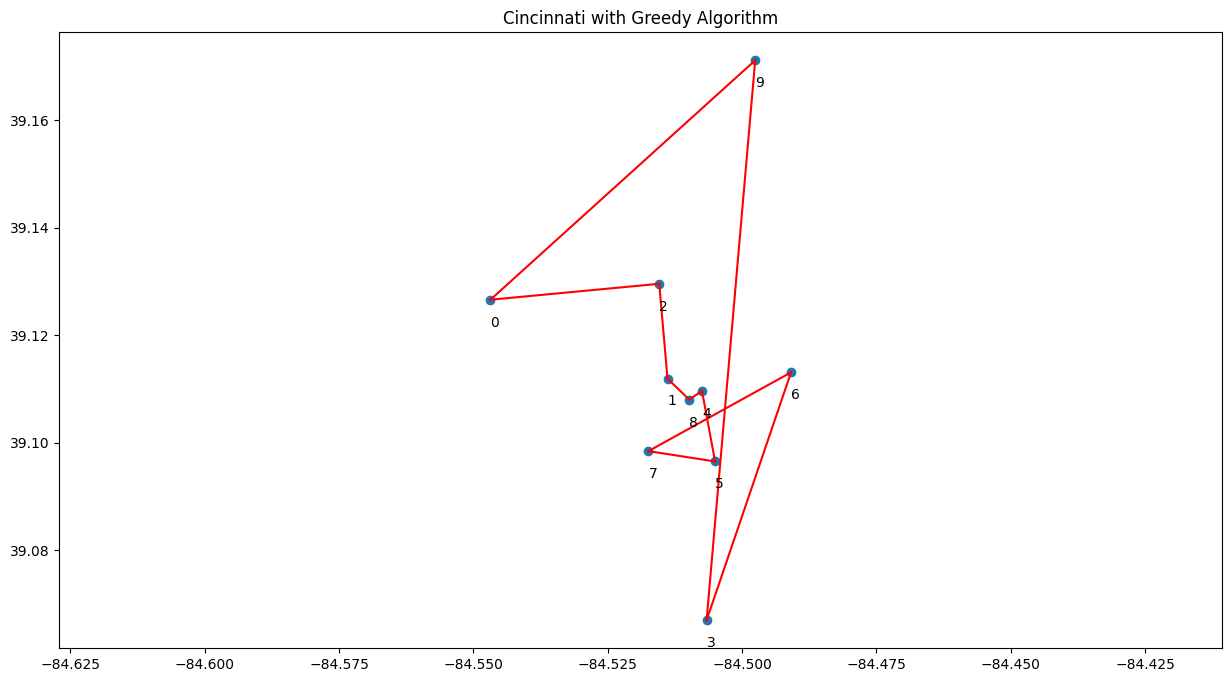

In [90]:
# Plot the cities and optimal path
plt.figure(figsize=(15, 8))
plt.scatter(df['Longitude (deg)'], df['Latitude (deg)'])
for i in range(len(df)):
    plt.text(df.loc[i, 'Longitude (deg)'], df.loc[i, 'Latitude (deg)']-0.005, str(df.loc[i, 'Index']))
for i in range(len(optimal_path)-1):
    start = df.loc[optimal_path[i], ['Longitude (deg)', 'Latitude (deg)']]
    end = df.loc[optimal_path[i+1], ['Longitude (deg)', 'Latitude (deg)']]
    plt.plot([start[0], end[0]], [start[1], end[1]], color='red')

plt.title('Cincinnati with Greedy Algorithm')  #change according to the selected city
plt.axis('equal')
plt.show()

In [91]:
def compute_total_distance(d_a_matrix, path):
    # Compute the total distance of the tour
    n = len(path)
    total_distance = 0.0
    for i in range(n):
        start = path[i]
        end = path[(i+1) % n]
        distance = d_a_matrix[start][end]
        total_distance += distance
    return total_distance

In [92]:
total= compute_total_distance(d_a_matrix, optimal_path)
total

34353.58269560644

##Genetic Algorithm Solution

In [93]:
# Data Load
atlanta = pd.read_csv("Atlanta.csv")
Cincinnati = pd.read_csv("Cincinnati.csv")
Philadelphia = pd.read_csv("Philadelphia.csv")
df= Cincinnati  #change according to the selected city

In [94]:
#Import needed packages
import numpy as np, random, operator, pandas as pd, matplotlib.pyplot as plt

In [95]:
#set seed for tuning the hyperparameters of GA function
import torch
import numpy as np
import random
import os

def my_seed_everywhere(seed: int = 42):
    random.seed(seed) # random
    np.random.seed(seed) # numpy
    os.environ["PYTHONHASHSEED"] = str(seed) # os
    # pytorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed) 
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False 

my_seed = 42
my_seed_everywhere(my_seed)

In [96]:
#Handle city delivery locations and distance measure with Harversine library
!pip install haversine
from haversine import haversine, Unit
class City:
    def __init__(self, x, y):
        self.x = x
        self.y = y
    
    def distance(self, city):
        a=(self.x,self.y)
        b=(city.x,city.y)
        distance=haversine(a,b,unit=Unit.METERS)
        return distance
       
    def __repr__(self):
        return "(" + str(self.x) + "," + str(self.y) + ")"

#Fitness function (larger the better)
class Fitness:
    def __init__(self, route):
        self.route = route
        self.distance = 0
        self.fitness= 0.0
    
    def routeDistance(self):
        if self.distance ==0:
            pathDistance = 0
            for i in range(0, len(self.route)):
                fromCity = self.route[i]
                toCity = None
                if i + 1 < len(self.route):
                    toCity = self.route[i + 1]
                else:
                    toCity = self.route[0]
                pathDistance += fromCity.distance(toCity)
            self.distance = pathDistance
        return self.distance
    
    def routeFitness(self):
        if self.fitness == 0:
            self.fitness = 1 / float(self.routeDistance())
        return self.fitness

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [97]:
#create population
def createRoute(cityList):
    route = random.sample(cityList, len(cityList))
    return route

def initialPopulation(popSize, cityList):
    population = []

    for i in range(0, popSize):
        population.append(createRoute(cityList))
    return population

In [98]:
#Determine fitness
def rankRoutes(population):
    fitnessResults = {}
    for i in range(0,len(population)):
        fitnessResults[i] = Fitness(population[i]).routeFitness()
    return sorted(fitnessResults.items(), key = operator.itemgetter(1), reverse = True)


In [99]:
# Select the mating pool (roulette wheel)
def selection(popRanked, eliteSize):
    selectionResults = []
    df = pd.DataFrame(np.array(popRanked), columns=["Index","Fitness"])
    df['cum_sum'] = df.Fitness.cumsum()
    df['cum_perc'] = 100*df.cum_sum/df.Fitness.sum()
    
    for i in range(0, eliteSize):
        selectionResults.append(popRanked[i][0])
    for i in range(0, len(popRanked) - eliteSize):
        pick = 100*random.random()
        for i in range(0, len(popRanked)):
            if pick <= df.iat[i,3]:
                selectionResults.append(popRanked[i][0])
                break
    return selectionResults
  
def matingPool(population, selectionResults):
    matingpool = []
    for i in range(0, len(selectionResults)):
        index = selectionResults[i]
        matingpool.append(population[index])
    return matingpool

In [100]:
#Ordered-Crossover
def breed(parent1, parent2):
    child = []
    childP1 = []
    childP2 = []
    
    geneA = int(random.random() * len(parent1))
    geneB = int(random.random() * len(parent1))
    
    startGene = min(geneA, geneB)
    endGene = max(geneA, geneB)

    for i in range(startGene, endGene):
        childP1.append(parent1[i])
        
    childP2 = [item for item in parent2 if item not in childP1]

    child = childP1 + childP2
    return child

def breedPopulation(matingpool, eliteSize):
    children = []
    length = len(matingpool) - eliteSize
    pool = random.sample(matingpool, len(matingpool))

    for i in range(0,eliteSize):
        children.append(matingpool[i])
    
    for i in range(0, length):
        child = breed(pool[i], pool[len(matingpool)-i-1])
        children.append(child)
    return children

In [101]:
#Mutation (Swap mutation)
def mutate(individual, mutationRate):
    for swapped in range(len(individual)):
        if(random.random() < mutationRate):
            swapWith = int(random.random() * len(individual))
            
            city1 = individual[swapped]
            city2 = individual[swapWith]
            
            individual[swapped] = city2
            individual[swapWith] = city1
    return individual

#Mutation through new population
def mutatePopulation(population, mutationRate):
    mutatedPop = []
    
    for ind in range(0, len(population)):
        mutatedInd = mutate(population[ind], mutationRate)
        mutatedPop.append(mutatedInd)
    return mutatedPop

In [102]:
#Repeat: rank the routes of current, select, crossover, and mutation
def nextGeneration(currentGen, eliteSize, mutationRate):
    popRanked = rankRoutes(currentGen)
    selectionResults = selection(popRanked, eliteSize)
    matingpool = matingPool(currentGen, selectionResults)
    children = breedPopulation(matingpool, eliteSize)
    nextGeneration = mutatePopulation(children, mutationRate)
    return nextGeneration

In [103]:
#Generate GA
def geneticAlgorithm(population, popSize, eliteSize, mutationRate, generations):
    pop = initialPopulation(popSize, population)
    print("Initial distance: " + str(1 / rankRoutes(pop)[0][1]))
    
    for i in range(0, generations):
        pop = nextGeneration(pop, eliteSize, mutationRate)
    
    print("Final distance: " + str(1 / rankRoutes(pop)[0][1]))
    bestRouteIndex = rankRoutes(pop)[0][0]
    bestRoute = pop[bestRouteIndex]
    return bestRoute

In [104]:
#Running the genetic algorithm

cityList = []

for ii,i in enumerate(df["Index"]):
  cityList.append(City(x=df["Latitude (deg)"][i], y=df["Longitude (deg)"][i]))
cityList

bestRoute=geneticAlgorithm(population=cityList, popSize=200, eliteSize=20, mutationRate=0.01, generations=500)

Initial distance: 30708.79576294545
Final distance: 28622.62932787465


In [105]:
city=[]
for i in bestRoute:
  city.append(cityList.index(i))


city

[5, 3, 7, 8, 4, 1, 0, 2, 9, 6]

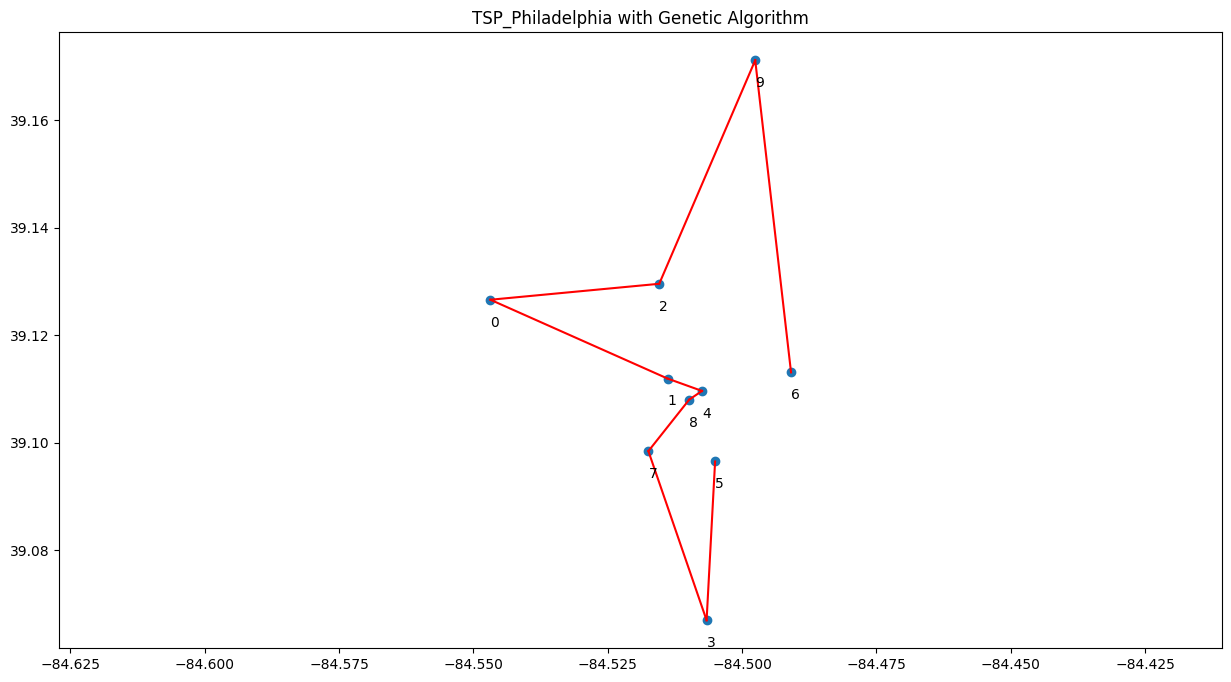

In [106]:
# Plot the cities and optimal path
plt.figure(figsize=(15, 8))
plt.scatter(df['Longitude (deg)'], df['Latitude (deg)'])
for i in range(len(df)):
    plt.text(df.loc[i, 'Longitude (deg)'], df.loc[i, 'Latitude (deg)']-0.005, str(df.loc[i, 'Index']))
for i in range(len(city)-1):
    start = df.loc[city[i], ['Longitude (deg)', 'Latitude (deg)']]
    end = df.loc[city[i+1], ['Longitude (deg)', 'Latitude (deg)']]
    plt.plot([start[0], end[0]], [start[1], end[1]], color='red')

plt.title('TSP_Philadelphia with Genetic Algorithm')  #change according to the selected city
plt.axis('equal')
plt.show()

In [107]:
#Plot of convergence history
def geneticAlgorithmPlot(population, popSize, eliteSize, mutationRate, generations):
    pop = initialPopulation(popSize, population)
    progress = []
    progress.append(1 / rankRoutes(pop)[0][1])
    
    for i in range(0, generations):
        pop = nextGeneration(pop, eliteSize, mutationRate)
        progress.append(1 / rankRoutes(pop)[0][1])
    
    plt.plot(progress)
    plt.ylabel('Distance')
    plt.xlabel('Generation')
    plt.show()

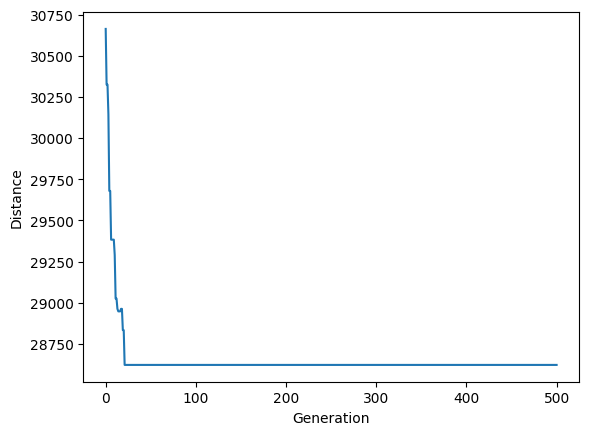

In [108]:
geneticAlgorithmPlot(population=cityList, popSize=200, eliteSize=20, mutationRate=0.01, generations=500)